# Phase Retrieval of Twisted Bilayer MoS2

In this tutorial notebook, we will reconstruct conventional virtual detectors, and phase contrast images of MoS2. We will generate these reconstructions:
* Virtual bright field image
* Virtual dark field image
* Differential phase contrast (DPC)
* Parallax depth sectioning
* Ptychography (single slice)

We have already applied the experimental calibrations, so the only other piece of information required is the accelerating voltage of 80 kV.

### Downloads

- [MoS2 twisted bilayer 4D-STEM dataset at bin 2](https://drive.google.com/file/d/1C3tXV5BXz0JXbmyu3wTu3NutuIYYsN8A/view?usp=sharing)

### Acknowledgements

This tutorial was created by the py4DSTEM instructor team:
- Colin Ophus (clophus@lbl.gov)
- Georgios Varnavides (gvarnavides@berkeley.edu)
- Stephanie Ribet (sribet@lbl.gov)

The 4D-STEM dataset used here was recorded by Zhen Chen in the Muller group, at Cornell University.  
The associated manuscript can be found here:
[Electron ptychography of 2D materials to deep sub-ångström resolution](https://doi.org/10.1038/s41586-018-0298-5)
We then binned the diffraction data by a factor of 2 to enable faster processing times.

Updated 2024 May 6

In [1]:
# !pip install py4DSTEM
%pip install py4DSTEM-lite

  Using cached numpy-2.2.6-cp310-cp310-manylinux_2_17_aarch64.manylinux2014_aarch64.whl.metadata (63 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 693.6/693.6 kB 7.6 MB/s  0:00:00
Using cached numpy-2.2.6-cp310-cp310-manylinux_2_17_aarch64.manylinux2014_aarch64.whl (14.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4━━━━━ 0/2 [numpy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [py4DSTEM-lite]0m [py4DSTEM-lite]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchvision 0.24.1 requires torch==2.9.1, but you have torch 2.5.0a0+872d972e41.nv24.8 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import py4DSTEM
print(py4DSTEM.__version__)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/home/henry/miniconda3/envs/ophuslab310/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/henry/miniconda3/envs/ophuslab310/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/henry/miniconda3/envs/ophuslab310/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/henry/miniconda3/envs/ophuslab310/lib/python3.10/site-packages/traitlets/config/appl

0.14.16


In [3]:
# Get the 4DSTEM data
py4DSTEM.io.gdrive_download(
    id_ = 'https://drive.google.com/uc?id=1C3tXV5BXz0JXbmyu3wTu3NutuIYYsN8A',
    destination = './',
    filename = 'ptycho_MoS2_bin2.h5',
    overwrite=True
)

Downloading...
From: https://drive.google.com/uc?id=1C3tXV5BXz0JXbmyu3wTu3NutuIYYsN8A
To: /home/henry/Desktop/ophuslab-work/20251221-ptycho_v1-bob/new/ptycho_MoS2_bin2.h5
100%|██████████| 88.2M/88.2M [00:04<00:00, 21.2MB/s]


In [4]:
file_path = "./"

file_data = file_path + 'ptycho_MoS2_bin2.h5'

# Load data, basic visualization

In [5]:
dataset = py4DSTEM.read(file_data)
dataset.calibration

Calibration( A Metadata instance called 'calibration', containing the following fields:

             Q_pixel_size:      3.2990832213275603
             R_pixel_size:      0.59
             Q_pixel_units:     mrad
             R_pixel_units:     A
             QR_flip:           False
             probe_semiangle:   6.486650552388484
             qx0_mean:          29.287584419369598
             qy0_mean:          30.34295690657806
)

We calculate and plot mean diffraction pattern:

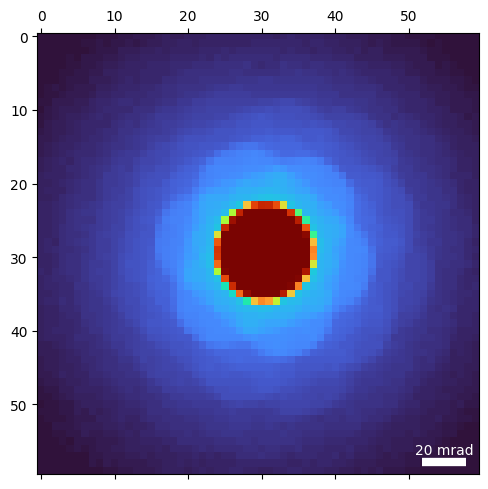

In [6]:
dataset.get_dp_mean();

py4DSTEM.show(
    dataset.tree('dp_mean'),
    power = 0.25,
    cmap = 'turbo',
)

The center beam is very bright, but this dataset contains much higher scattering angles. To see both the high intensity and low intensity regions of the mean diffraction pattern, we can use logarithmic intensity scaling:

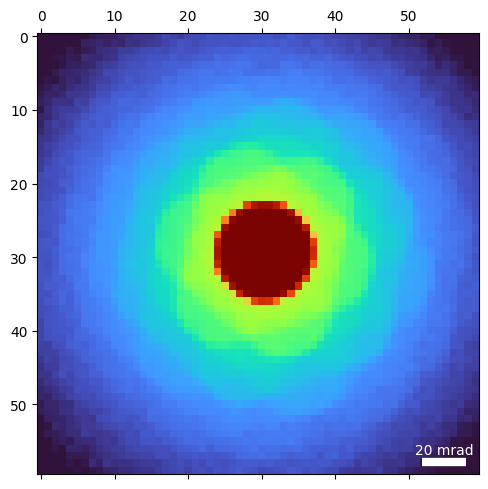

In [7]:
py4DSTEM.show(
    dataset.tree('dp_mean'),
    scaling = 'log',
    cmap = 'turbo',
)

Note also that we already have a dimensioned scalebar - this dataset has already had the pixel size calibration added in real and diffraction space.

# Virtual images

We estimate the probe radius and create BF and DF virtual images by using the detected radius

100%|██████████| 6120/6120 [00:00<00:00, 35675.96it/s]


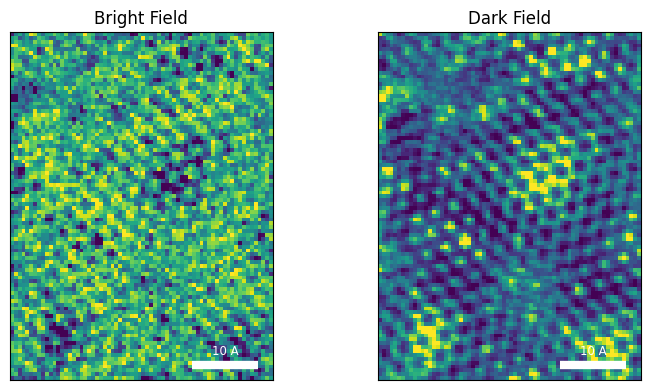

In [8]:
probe_radius_pixels, probe_qx0, probe_qy0 = dataset.get_probe_size(plot = False)
expand_BF = 2.0

center = (probe_qx0, probe_qy0)
radius_BF = probe_radius_pixels + expand_BF
radii_DF = (probe_radius_pixels + expand_BF, 1e3)

dataset.get_virtual_image(
    mode = 'circle',
    geometry = (center,radius_BF),
    name = 'bright_field',
    shift_center = False,
)
dataset.get_virtual_image(
    mode = 'annulus',
    geometry = (center,radii_DF),
    name = 'dark_field',
    shift_center = False,
);

py4DSTEM.show(
    [
        dataset.tree('bright_field'),
        dataset.tree('dark_field'),
    ],
    cmap='viridis',
    ticks = False,
    axsize=(4,4),
    title=['Bright Field','Dark Field'],
)

As we can see, this sample consists of a twisted bilayer of MoS2 which form a moire lattice. When the 2 lattices are aligned, we get brighter atomic columns in the dark field image.  When they are misaligned, we see lower contrast.

# Differential Phase Contrast (DPC)

In DPC, we measure the center of mass (CoM) of the electron probe in diffraction space for each probe position. This CoM corresponds to the average in-plane momentum of the electron beam, which is proportional to the electic field. In matter, the electric field is the derivative of the sample's electrostatic potential, which in turn is proportional to the sample's phase shift. Hence if we numerically integrate the signal, we can reconstruct the phase.

Best fit rotation = 28 degrees.


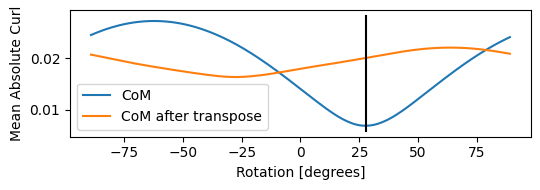

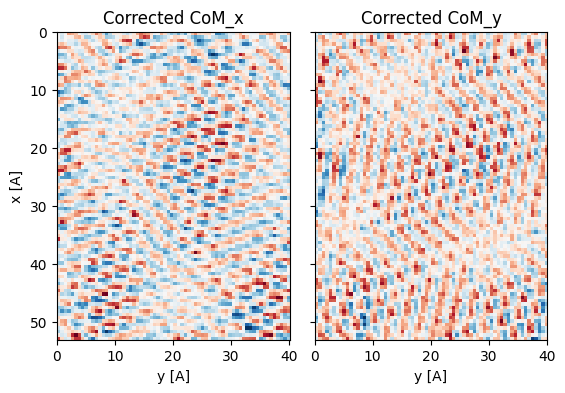

In [9]:
dpc = py4DSTEM.process.phase.DPC(
    datacube=dataset,
    energy = 300e3,
).preprocess()

We first estimate the relative rotation between the real space scanning coordinate system and the diffraction space detector coordinates. This value can be non-zero if the STEM scan coils are rotated to some angle, if the detector is rotated around the optical axis, or if the data has been read incorrectly (transposing x and y or kx and ky for example).

Reconstructing phase: 100%|██████████| 8/8 [00:00<00:00, 263.47 iter/s]


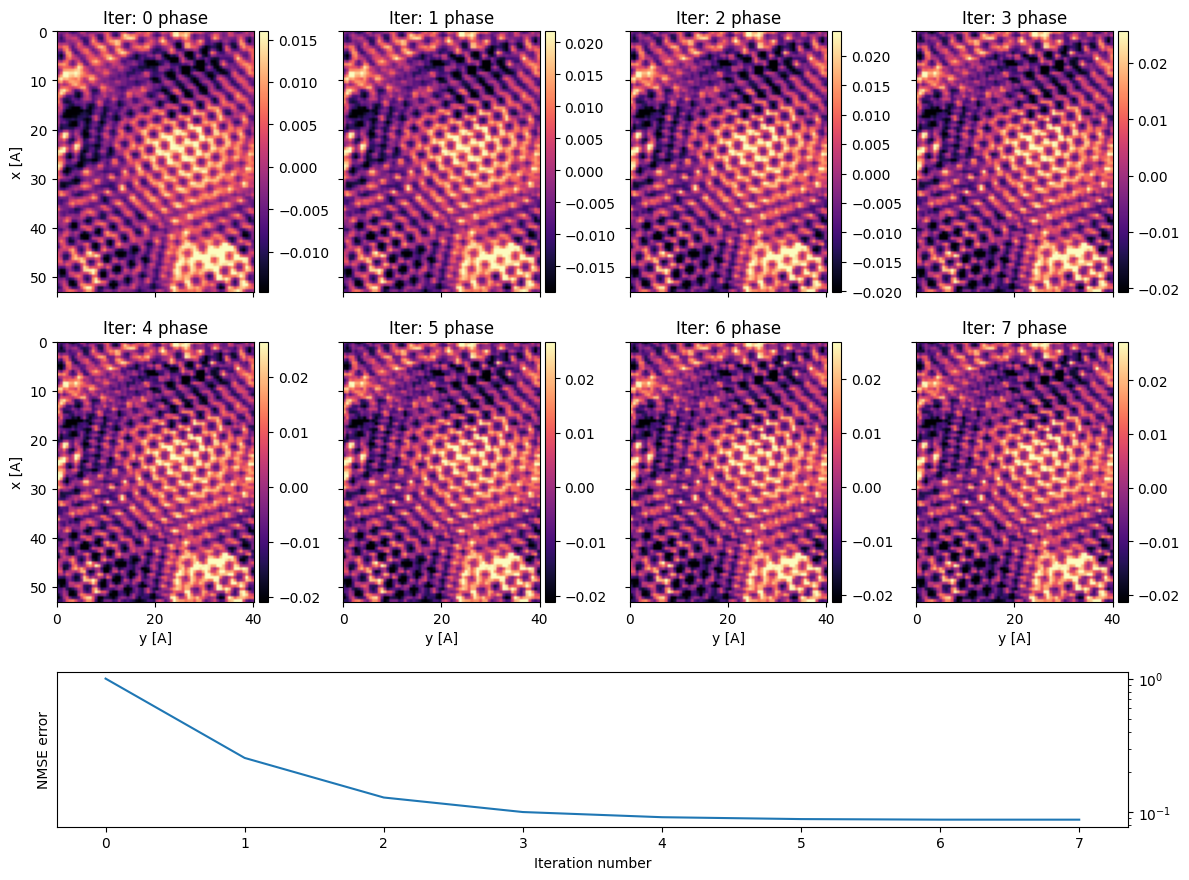

In [10]:
dpc = dpc.reconstruct(
    max_iter=8,
    store_iterations=True,
    reset=True,
).visualize(
    iterations_grid='auto',
    figsize=(12,9)
);

We see that the lattice image is somewhat sharper, and has a higher signal to noise. This is because phase contrast imaging methods such as DPC reconstructions are more dose-efficient than bright field or dark field imaging for thin samples. However the resolution is still limited to the STEM probe sampling density.

# Parallax Imaging

Each pixel in diffraction space can be used to form a virtual image.  On the bright field disk, each of these pixels represents a plane wave of electrons which impacted the sample at a different angle, and because the probe is defocused, a different position on the sample surface. We can computationally align each of these images by using the "parallax operator." This operator corrects the geometric intercepts of each virtual image to be properly focused by aligning the virtual images. The final step is to correct the defocus either by solving the full complex wave (S-matrix reconstruction) or assuming a weak phase object and using contrast transfer function (CTF)-correction.

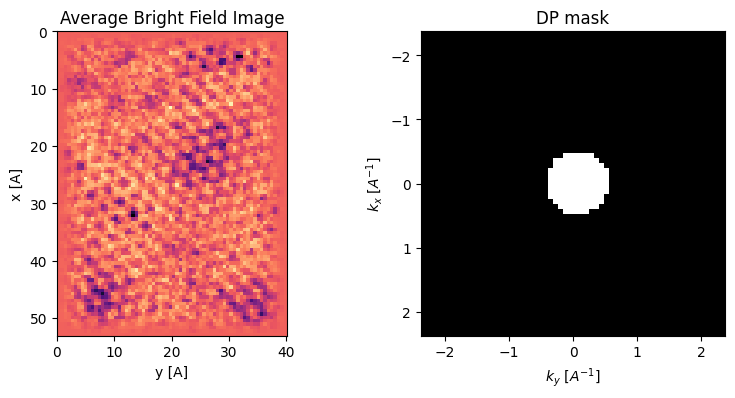

In [11]:
parallax = py4DSTEM.process.phase.Parallax(
    datacube=dataset,
    energy = 80e3,
    object_padding_px=(16,16),
    #device = "gpu",
    verbose=True,
).preprocess(
    normalize_images=True,
    plot_average_bf=True,
    edge_blend=8,
)

Alignment at bin 4: 100%|██████████| 11/11 [00:00<00:00, 313.36 image subsets/s]


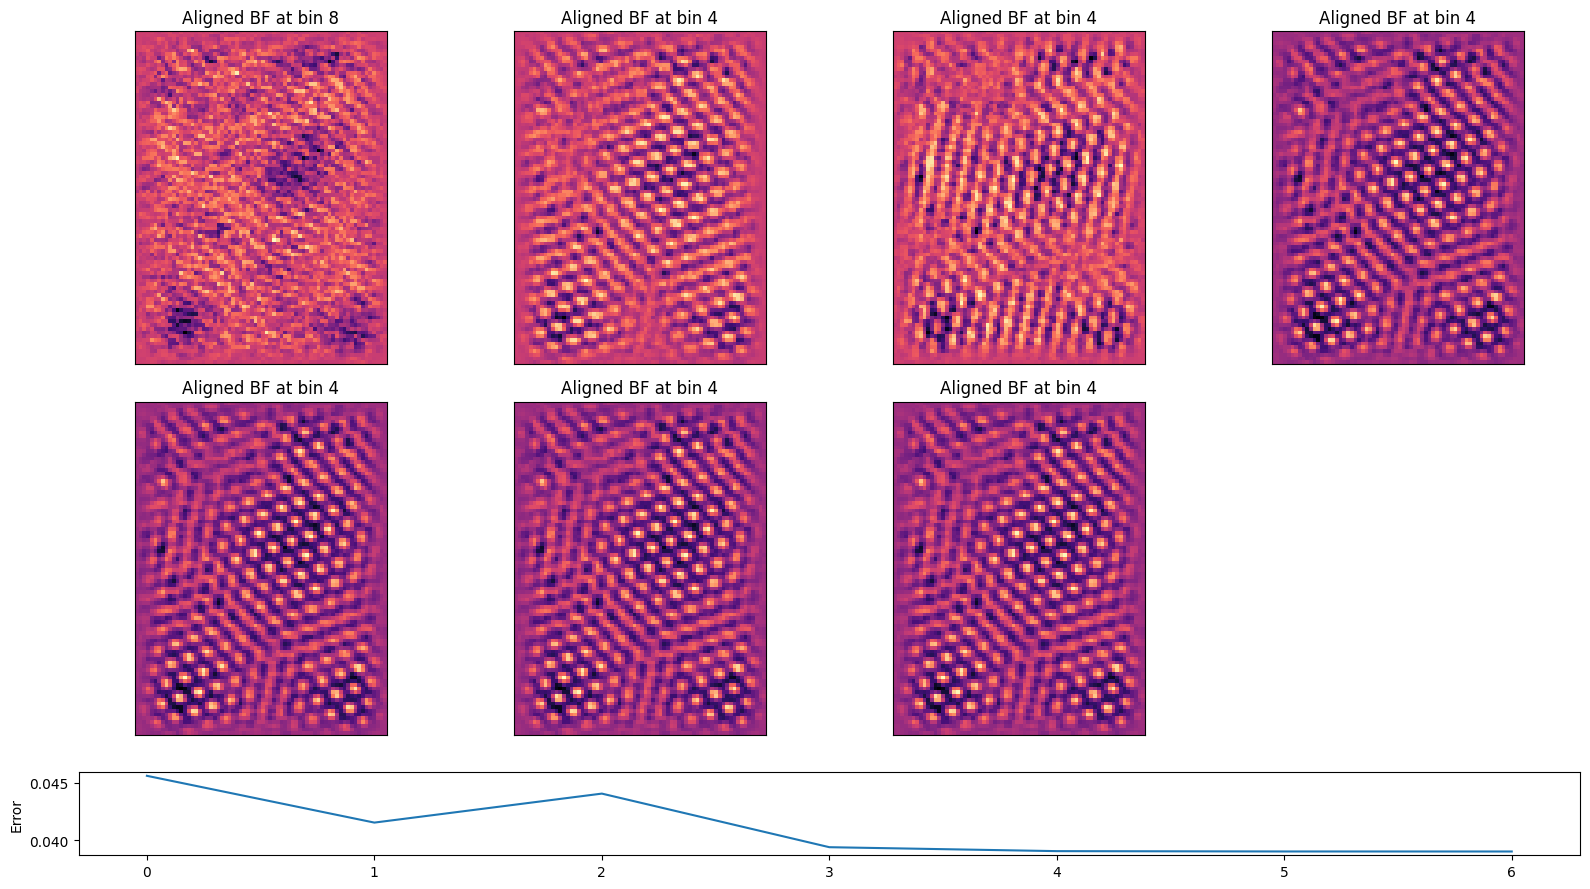

In [12]:
parallax = parallax.reconstruct(
    reset=True,
    regularize_shifts=False,
    min_alignment_bin = 4,
    num_iter_at_min_bin = 6,
)

The tilt-shift parallax correction has brought the sum of all images into focus. We next try the CTF-correction method to reconstruct the object phase.

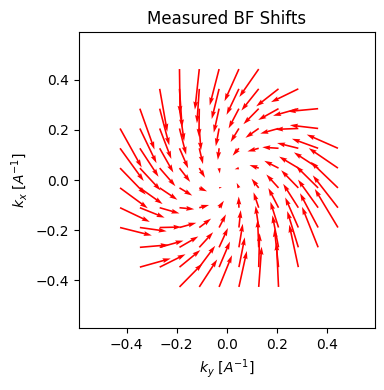

In [13]:
parallax.show_shifts()

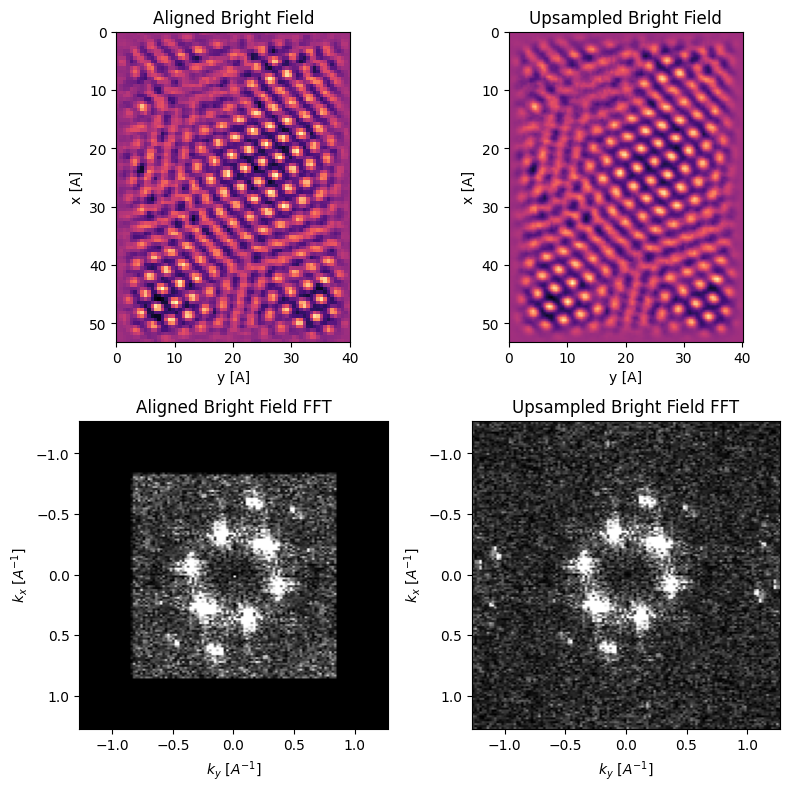

In [14]:
parallax = parallax.subpixel_alignment(
    kde_upsample_factor=1.5,
    plot_upsampled_BF_comparison=True,
    plot_upsampled_FFT_comparison=True,
)

Rotation of Q w.r.t. R = 29.217 deg
Astigmatism (A1x,A1y)  = (-10,6) Ang
Aberration C1          =  -58 Ang
Defocus dF             = 58 Ang
Transpose              = False


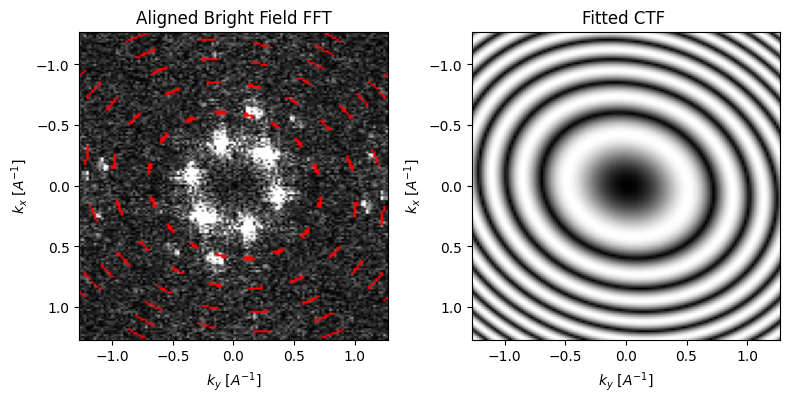

In [15]:
parallax = parallax.aberration_fit(
    plot_CTF_comparison=True,
)

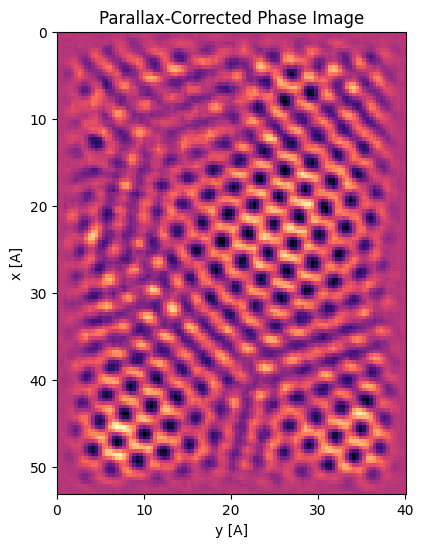

In [16]:
parallax = parallax.aberration_correct(
    use_CTF_fit=True,
)

# Ptychography

To reconstruct the complex object wave including both amplitude and phase, while simultaneously solving for the probe aberrations and deconvolving the probe, we will use ptychography. Notes:
- We get the probe convergence semiangle from the pixel size and estimated radius in pixels
- We use the rotation estimate from the previous parallax measurement.
- We use the initial defocus estimate from the previous parallax measurement.

In [17]:
semiangle_cutoff = dataset.calibration.get_Q_pixel_size() * probe_radius_pixels
print('semiangle cutoff estimate = ' + str(np.round(semiangle_cutoff,decimals=1)) + ' mrads')

defocus = parallax.aberration_C1
print('estimated defocus         = ' + str(np.round(defocus*-1,decimals=2)) + ' Angstroms')

rotation_degrees = np.rad2deg(parallax.rotation_Q_to_R_rads)
print('estimated rotation        = ' + str(np.round(rotation_degrees,decimals=2)) + ' deg')

semiangle cutoff estimate = 21.4 mrads
estimated defocus         = 57.86 Angstroms
estimated rotation        = 29.22 deg


Since the sample is thin-enough to be treated as a pure-phase object, we specify `object_type='potential'` to instruct the algorithm to use a real-valued array to represent the sample potential  
(i.e. implicitly assume the amplitude of the complex reconstructed object is unity).  
Also note we specified `object_padding_px=(0,0)` to save on memory, since the dataset is almost completely in-focus (small probe-extent)

Best fit rotation forced to 29 degrees.
Transpose of intensities forced to False.
Normalizing amplitudes: 100%|██████████| 6120/6120 [00:01<00:00, 3693.07probe position/s]


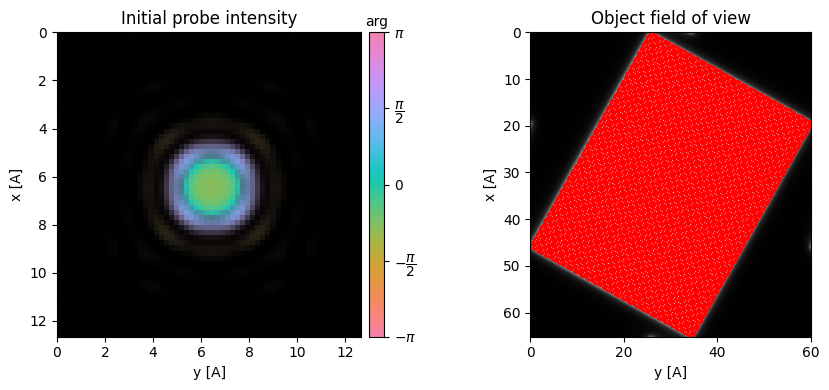

In [18]:
ptycho = py4DSTEM.process.phase.SingleslicePtychography(
    datacube=dataset,
    device = 'cpu',
    energy = 80e3,
    semiangle_cutoff = semiangle_cutoff, # 21.4
    defocus = defocus, # 54
    # object_type='potential',
    object_padding_px=(0,0),
).preprocess(
    plot_center_of_mass = False,
    plot_probe_overlaps = True,
    force_com_rotation = rotation_degrees, # 33
    force_com_transpose = False,
)

Performing 32 iterations using a complex object type, with the gradient-descent algorithm, with normalization_min: 1 and step _size: 0.5.
Reconstructing object and probe: 100%|██████████| 32/32 [03:11<00:00,  6.00s/ iter]


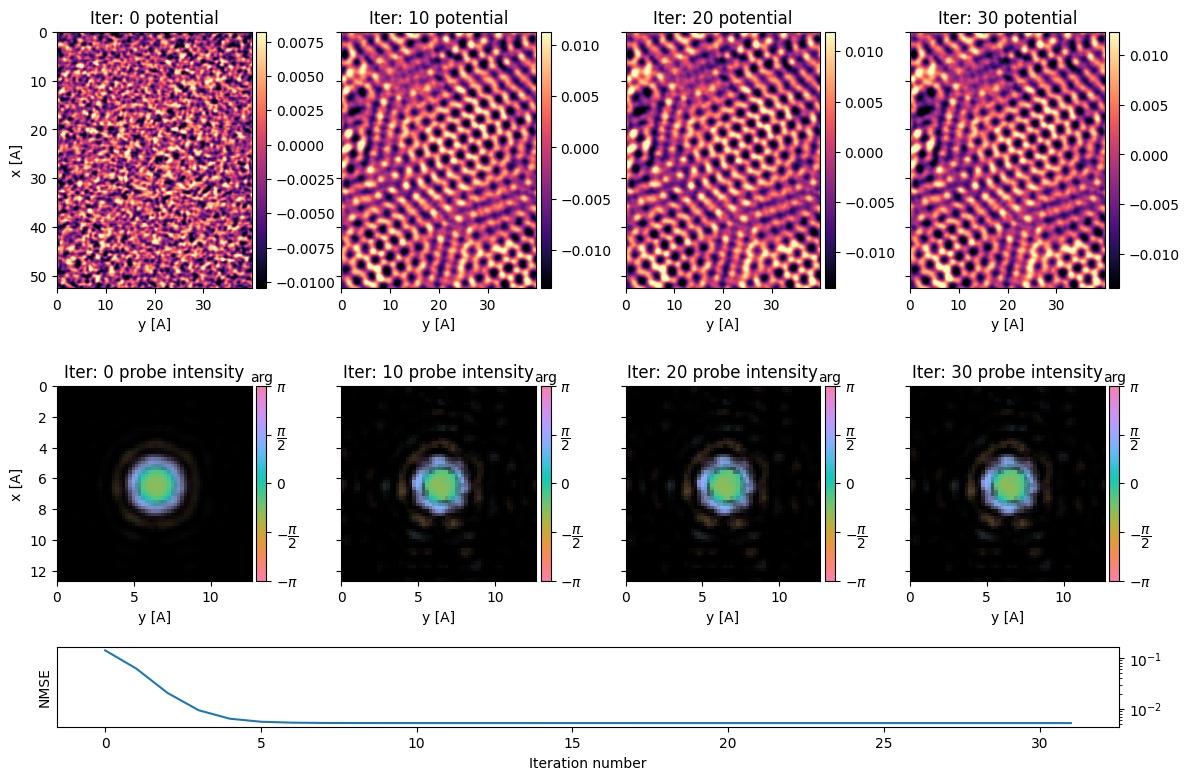

In [19]:
ptycho = ptycho.reconstruct(
    reset = True,
    store_iterations = True,
    num_iter = 32,
    step_size = 0.5,
    gaussian_filter_sigma = 0.2,
).visualize(
    iterations_grid='auto',
    figsize=(12,8),
)

# Comparison

Now let's compare the different imaging methods side-by-side!

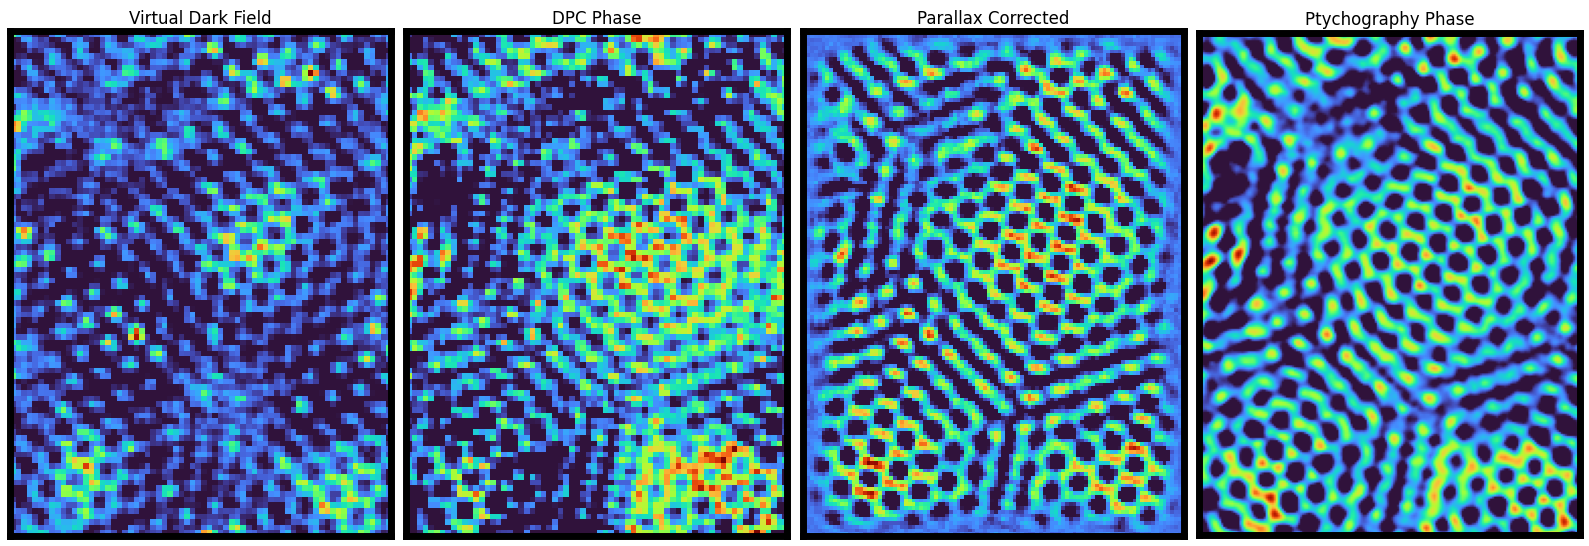

In [20]:
from scipy.ndimage import gaussian_filter

d_obj = gaussian_filter(dpc.object_phase,0.2/dpc.sampling[0])
p_obj = gaussian_filter(parallax.object_cropped,0.2/parallax._scan_sampling[0]/parallax._kde_upsample_factor)
# obj = ptycho.object_cropped
obj = np.angle(ptycho.object_cropped)

fig, ax = py4DSTEM.show(
    [
        dataset.tree('dark_field').data,
        d_obj,
        p_obj,
        obj,
    ],
    vmin = 0.25,
    vmax = 1,
    ticks = False,
    cmap = 'turbo',
    axsize = (4,6),
    returnfig=True,
    title = [
        'Virtual Dark Field',
        'DPC Phase',
        'Parallax Corrected',
        'Ptychography Phase',
    ],
    bordercolor = 'k',
)